In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots

#plt.style.use('science')
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']

In [2]:
def compute_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    print(n_indep_realizations)
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors

### Rossler, identical

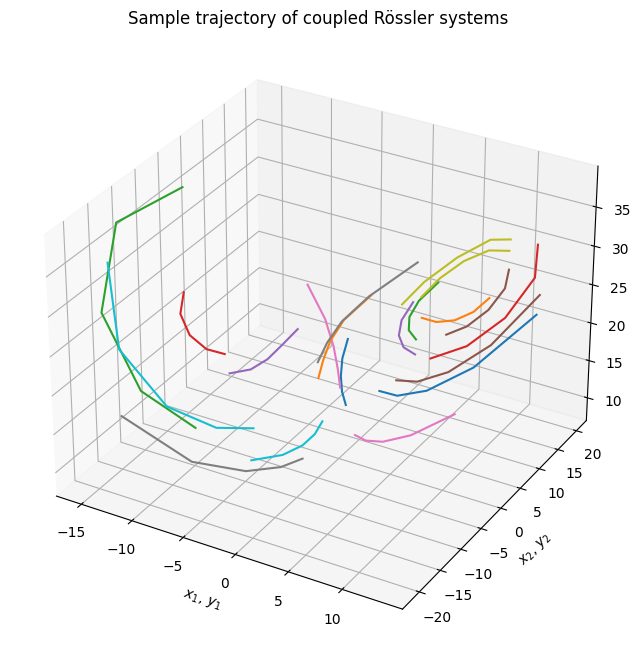

In [45]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
for seed in range(20):
    trajectory = pickle.load(open(f"../../trajs/lorenz/seed{seed}_ieps15.p","rb"))

    start_plot = 10000
    end_plot = 10005

    x_1 = trajectory[start_plot:end_plot,1]
    x_2 = trajectory[start_plot:end_plot,2]
    x_3 = trajectory[start_plot:end_plot,3]
    y_1 = trajectory[start_plot:end_plot,4]
    y_2 = trajectory[start_plot:end_plot,5]
    y_3 = trajectory[start_plot:end_plot,6]

    ax.plot3D(x_1, x_2, x_3)
    #ax.plot3D(y_1, y_2, y_3)

    ax.set_title("Sample trajectory of coupled Rössler systems")
    ax.set_xlabel("$x_1,\,y_1$")
    ax.set_ylabel("$x_2,\,y_2$")
    ax.set_zlabel("$x_3,\,y_3$")
fig.show()

-10.183883
-1.684506
-4.215819
-5.431023
-8.102669
-3.781539
-9.580168
-10.416307
-6.129420
-9.130646
-8.571737
-7.838667
-1.660951
-6.646434
-14.036230
-10.132192
-12.007453
-4.398043
-3.992370
-1.395869


(array([1., 1., 1., 4., 3., 1., 2., 3., 1., 3.]),
 array([-14.03623029, -12.77219414, -11.50815799, -10.24412183,
         -8.98008568,  -7.71604953,  -6.45201337,  -5.18797722,
         -3.92394107,  -2.65990491,  -1.39586876]),
 <BarContainer object of 10 artists>)

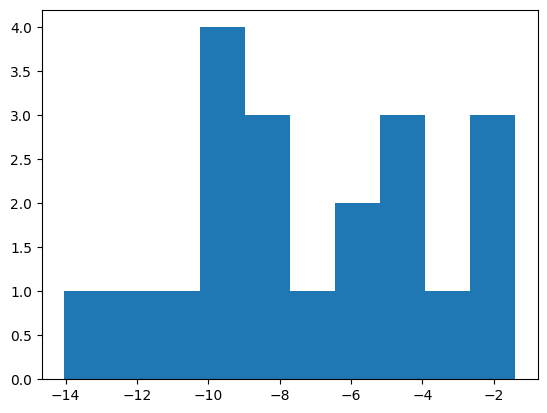

In [81]:
coord = 0
for i in range(20):
    print(f"{init_cond[i,coord]:3f}")
plt.hist(init_cond[:,coord])

In [82]:
epsilons = np.linspace(0.,0.25,30)
alphas = np.linspace(0.,0.25,50)

info_imbalances_X_to_Y = np.zeros((20,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((20,len(epsilons),len(alphas))) 

for seed in range(20):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./pickles/rossler_id/seed{seed}.p","rb"))
print(info_imbalances_X_to_Y.shape, info_imbalances_Y_to_X.shape)

(20, 30, 50) (20, 30, 50)


20
20


Text(0, 0.5, 'Imbalance Gain [%]')

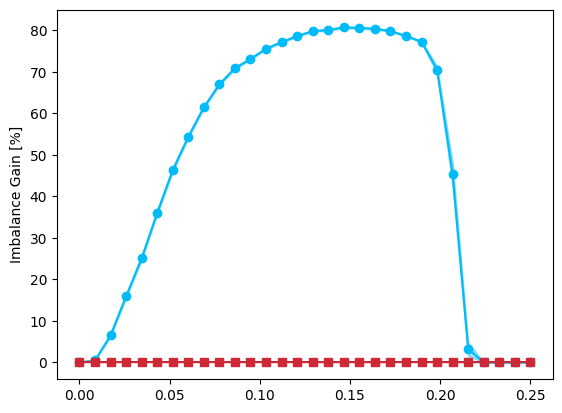

In [83]:
IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X)

plt.plot()
plt.plot(epsilons, IGs_X_to_Y, markers[0], color=colors[0], label="$X\\rightarrow Y$")
plt.plot(epsilons, IGs_Y_to_X, markers[1], color=colors[1], label="$Y\\rightarrow X$")
plt.fill_between(epsilons, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, color=colors[0], alpha=0.4)
plt.fill_between(epsilons, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, color=colors[1], alpha=0.4)
plt.ylabel("Imbalance Gain [%]")
#plt.set_xticks([])
#plt.legend()

### Rossler, different

In [86]:
epsilons = np.linspace(0.,0.25,30)
alphas = np.linspace(0.,0.25,50)

info_imbalances_X_to_Y = np.zeros((20,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((20,len(epsilons),len(alphas))) 

for seed in range(20):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./pickles/rossler_diff/seed{seed}.p","rb"))
print(info_imbalances_X_to_Y.shape, info_imbalances_Y_to_X.shape)

(20, 30, 50) (20, 30, 50)


20
20


Text(0, 0.5, 'Imbalance Gain [%]')

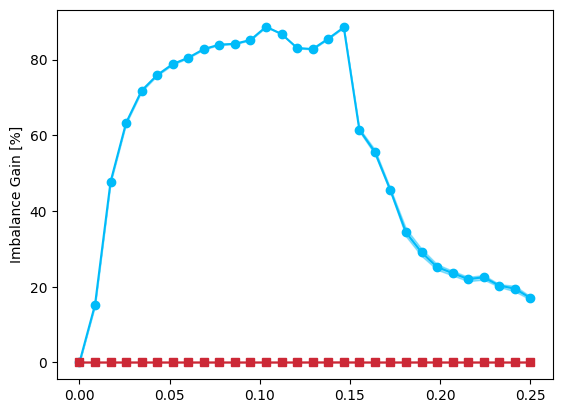

In [87]:
IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X)

plt.plot()
plt.plot(epsilons, IGs_X_to_Y, markers[0], color=colors[0], label="$X\\rightarrow Y$")
plt.plot(epsilons, IGs_Y_to_X, markers[1], color=colors[1], label="$Y\\rightarrow X$")
plt.fill_between(epsilons, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, color=colors[0], alpha=0.4)
plt.fill_between(epsilons, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, color=colors[1], alpha=0.4)
plt.ylabel("Imbalance Gain [%]")
#plt.set_xticks([])
#plt.legend()

### Lorenz

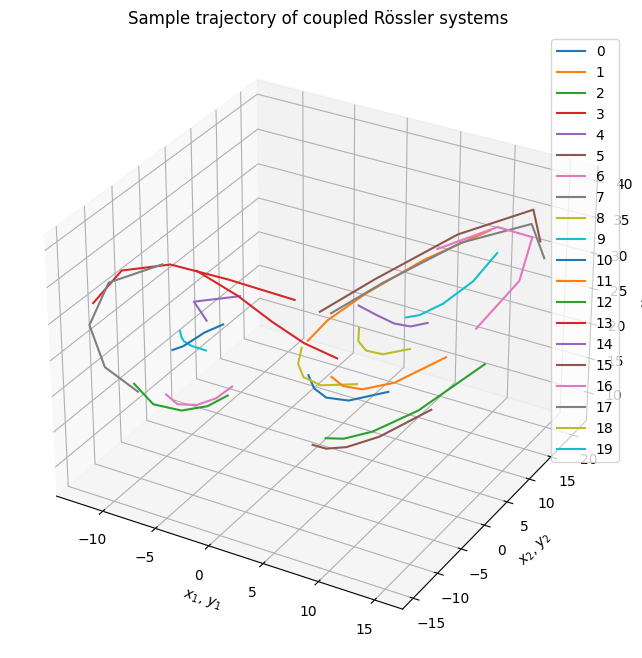

In [30]:
init_cond = np.zeros((20,6))
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
for seed in range(20):
    trajectory = pickle.load(open(f"../../trajs/lorenz_longer/seed{seed}_ieps28.p","rb"))

    start_plot = 100580
    end_plot = 100585

    x_1 = trajectory[start_plot:end_plot,1]
    x_2 = trajectory[start_plot:end_plot,2]
    x_3 = trajectory[start_plot:end_plot,3]
    y_1 = trajectory[start_plot:end_plot,4]
    y_2 = trajectory[start_plot:end_plot,5]
    y_3 = trajectory[start_plot:end_plot,6]

    #ax.plot3D(x_1, x_2, x_3, label=str(seed))
    ax.plot3D(y_1, y_2, y_3, label=str(seed))

    ax.set_title("Sample trajectory of coupled Rössler systems")
    ax.set_xlabel("$x_1,\,y_1$")
    ax.set_ylabel("$x_2,\,y_2$")
    ax.set_zlabel("$x_3,\,y_3$")
    init_cond[seed] = trajectory[5000,1:]
ax.legend()
fig.show()

(array([1.2700e+03, 1.9821e+04, 5.7298e+04, 6.1667e+04, 4.1632e+04,
        1.9567e+04, 3.4540e+03, 2.8000e+02, 1.1000e+01, 1.0000e+00]),
 array([ 0.        ,  7.38064065, 14.7612813 , 22.14192195, 29.52256261,
        36.90320326, 44.28384391, 51.66448456, 59.04512521, 66.42576586,
        73.80640651]),
 <BarContainer object of 10 artists>)

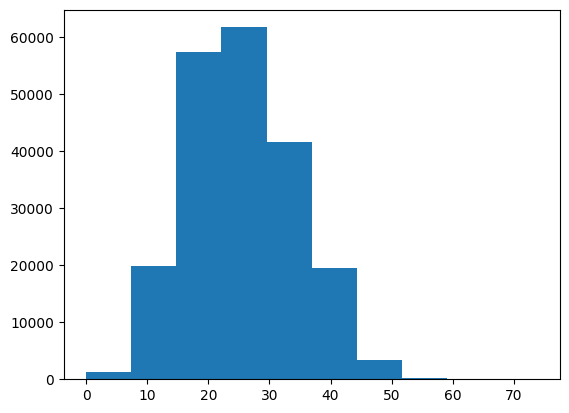

In [120]:
coord = 6
plt.hist(trajectory[:,coord])

In [8]:
epsilons = np.linspace(0.,0.3,31)
alphas = np.linspace(0.,0.3,50)

info_imbalances_X_to_Y = np.zeros((20,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((20,len(epsilons),len(alphas))) 

for seed in range(20):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./pickles/lorenz/seed{seed}.p","rb"))
print(info_imbalances_X_to_Y.shape, info_imbalances_Y_to_X.shape)

(20, 31, 50) (20, 31, 50)


20
20


Text(0, 0.5, 'Imbalance Gain [%]')

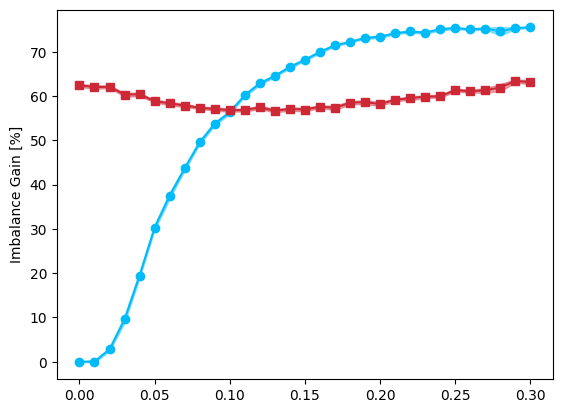

In [9]:
IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X)

plt.plot()
plt.plot(epsilons, IGs_X_to_Y, markers[0], color=colors[0], label="$X\\rightarrow Y$")
plt.plot(epsilons, IGs_Y_to_X, markers[1], color=colors[1], label="$Y\\rightarrow X$")
plt.fill_between(epsilons, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, color=colors[0], alpha=0.4)
plt.fill_between(epsilons, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, color=colors[1], alpha=0.4)
plt.ylabel("Imbalance Gain [%]")
#plt.set_xticks([])
#plt.legend()

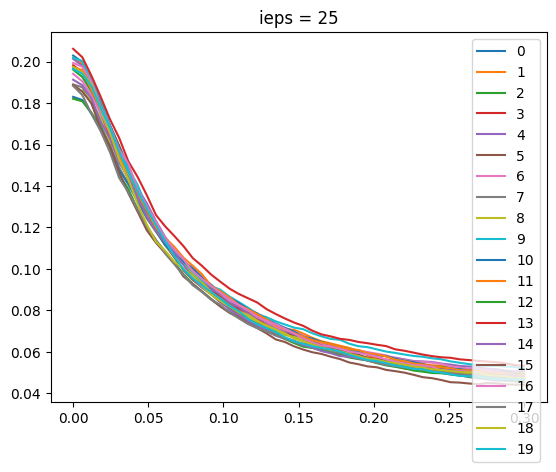

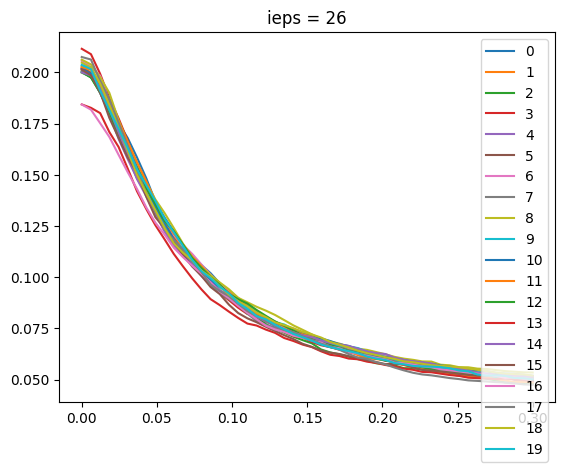

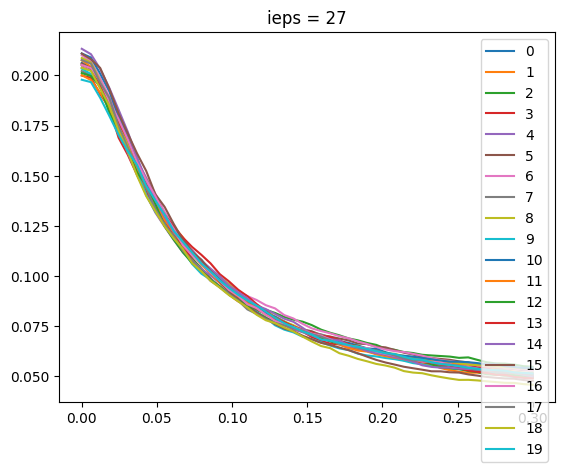

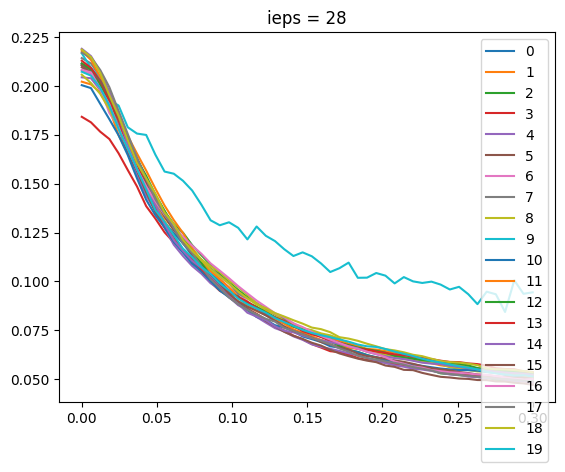

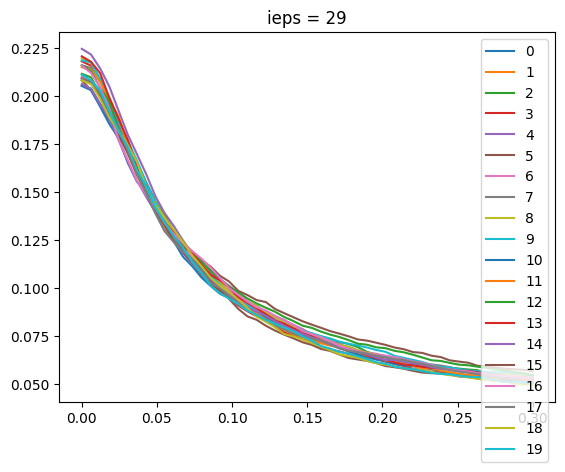

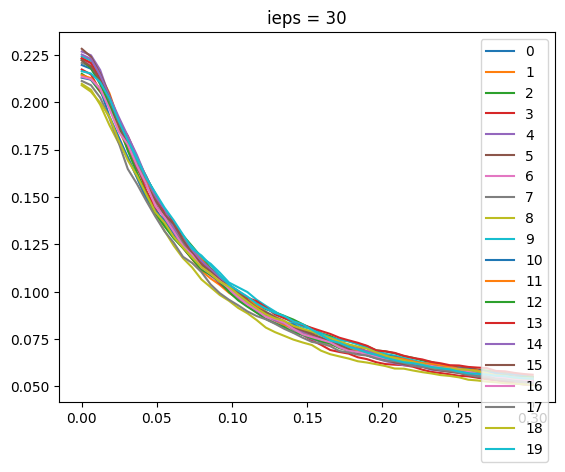

In [10]:
for ieps in range(25,31):
    for seed in range(20):
        plt.plot(alphas,info_imbalances_X_to_Y[seed,ieps], label=str(seed))
        plt.title("ieps = "+str(ieps))
    plt.legend()
    plt.show()

### Lorenz 96

In [144]:
epsilons = np.linspace(0.,0.3,31)
alphas = np.linspace(0.,0.3,50)

info_imbalances_X_to_Y = np.zeros((20,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((20,len(epsilons),len(alphas))) 

for seed in range(20):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./pickles/lorenz96/seed{seed}.p","rb"))
print(info_imbalances_X_to_Y.shape, info_imbalances_Y_to_X.shape)

(20, 31, 50) (20, 31, 50)


20


20


Text(0, 0.5, 'Imbalance Gain [%]')

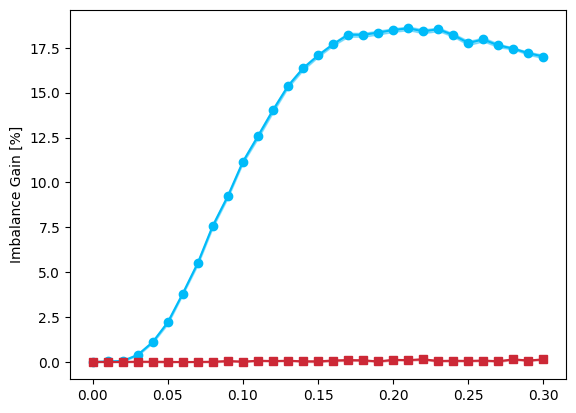

In [145]:
IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X)

plt.plot()
plt.plot(epsilons, IGs_X_to_Y, markers[0], color=colors[0], label="$X\\rightarrow Y$")
plt.plot(epsilons, IGs_Y_to_X, markers[1], color=colors[1], label="$Y\\rightarrow X$")
plt.fill_between(epsilons, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, color=colors[0], alpha=0.4)
plt.fill_between(epsilons, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, color=colors[1], alpha=0.4)
plt.ylabel("Imbalance Gain [%]")
#plt.set_xticks([])
#plt.legend()